<div style="background:linear-gradient(135deg,#14555A 0%,#0B3538 100%);border-radius:8px;padding:34px 30px;text-align:center;"><div style="color:#D98E32;font-size:13px;letter-spacing:3px;font-weight:700;">UNIFESP · CÁLCULO NUMÉRICO</div><div style="color:#FFFFFF;font-size:27px;font-weight:700;margin-top:12px;line-height:1.3;">Atividade Prática II<br>Estabilidade Numérica e Overflow</div><div style="height:2px;background:#D98E32;width:90px;margin:20px auto;"></div><div style="color:#D8E8E6;font-size:15px;">Escoamento transiente entre placas paralelas</div><div style="color:#D8E8E6;font-size:14px;margin-top:18px;">Discentes: <b>Luiz Ricardo e Matheus Bueno</b> &nbsp;·&nbsp; Docente: Profª Raquel J. Lobosco</div></div>

### Apresentação

O objetio é estudar a relação entre o passo de tempo, a estabilidade numérica e a ocorrência de *overflow* na
simulação do escoamento de Couette transiente. A equação governante é a da difusão de quantidade de movimento,

$$\frac{\partial u}{\partial t} = \nu\,\frac{\partial^2 u}{\partial y^2},
\qquad u(0,t)=U,\quad u(H,t)=0,\quad u(y,0)=0,$$

discretizada por Euler explícito no tempo e diferenças finitas centrais no espaço:

$$u_i^{\,n+1} = u_i^{\,n} + r\left(u_{i+1}^{\,n} - 2u_i^{\,n} + u_{i-1}^{\,n}\right),
\qquad r = \frac{\nu\,\Delta t}{\Delta y^{2}}.$$

**Dados:** $H = 0{,}01$ m · $\nu = 10^{-4}$ m²/s · $U = 1$ m/s · 21 pontos de malha.

**Sequência** (1) previsão analítica da estabilidade · (2) detecção de *overflow* nos quatro testes ·
(3) interpretação física · (4) efeito do tipo numérico · (5) refinamento da malha ·
(6) verificação do perfil de velocidade · (7) conclusão.

<div style="background-color:#14555A;border-left:7px solid #D98E32;border-radius:5px;padding:11px 18px;margin:26px 0 10px 0;"><span style="color:#D98E32;font-size:13px;letter-spacing:2px;font-weight:700;">SEÇÃO 0</span><br><span style="color:#FFFFFF;font-size:19px;font-weight:600;">Configuração do ambiente</span></div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Paleta do relatorio
COR = ["#14555A", "#D98E32", "#7A3B69", "#3F7D20"]
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.prop_cycle": plt.cycler(color=COR),
    "axes.edgecolor": "#7F9C9A",
    "axes.labelcolor": "#14555A",
    "axes.titlesize": 13,
    "axes.titleweight": "600",
    "grid.color": "#DCE8E7",
    "font.size": 11,
})

# Parametros fisicos e de malha
H = 0.01        # distancia entre as placas [m]
nu = 1e-4       # viscosidade cinematica [m2/s]
U = 1.0         # velocidade da placa movel [m/s]
pontos = 21     # pontos de malha, incluindo as paredes

dy = H / (pontos - 1)
dt_max = dy**2 / (2 * nu)
print(f"dy     = {dy} m")
print(f"dt_max = {dt_max:.5f} s")

dy     = 0.0005 m
dt_max = 0.00125 s


<div style="background-color:#14555A;border-left:7px solid #D98E32;border-radius:5px;padding:11px 18px;margin:26px 0 10px 0;"><span style="color:#D98E32;font-size:13px;letter-spacing:2px;font-weight:700;">SEÇÃO 1</span><br><span style="color:#FFFFFF;font-size:19px;font-weight:600;">Verificação da estabilidade</span></div>

A condição de estabilidade do esquema explícito para a difusão unidimensional é $r \le 1/2$, o que equivale a
$\Delta t \le \Delta y^{2}/(2\nu)$. Com 21 pontos:

$$\Delta y = \frac{H}{20} = 5\times10^{-4}\ \text{m},
\qquad \Delta t_{max} = \frac{(5\times10^{-4})^{2}}{2\times10^{-4}} = 1{,}25\times10^{-3}\ \text{s}.$$

A classificação de cada caso é obtida a seguir, previamente à execução da simulação.

In [ ]:
for nome, dt in [("Caso A", 0.001), ("Caso B", 0.002)]:
    r = nu * dt / dy**2
    print(f"{nome}: dt = {dt} s | r = {r:.2f} | dt/dt_max = {dt/dt_max:.2f} "
          f"-> {'ESTAVEL' if r <= 0.5 else 'INSTAVEL'}")

<table style="border-collapse:collapse;font-size:14px;margin:8px 0;"><tr style="background-color:#14555A;color:#FFF;"><th style="padding:8px 16px;text-align:left;">Caso</th><th style="padding:8px 16px;">&Delta;t (s)</th><th style="padding:8px 16px;">r</th><th style="padding:8px 16px;">&Delta;t / &Delta;t<sub>max</sub></th><th style="padding:8px 16px;">Previsão</th></tr><tr style="background-color:#EEF5F4;"><td style="padding:8px 16px;"><b>A</b></td><td style="padding:8px 16px;text-align:center;">0,001</td><td style="padding:8px 16px;text-align:center;">0,40</td><td style="padding:8px 16px;text-align:center;">0,80</td><td style="padding:8px 16px;text-align:center;color:#2E6B3E;"><b>Estável</b></td></tr><tr><td style="padding:8px 16px;"><b>B</b></td><td style="padding:8px 16px;text-align:center;">0,002</td><td style="padding:8px 16px;text-align:center;">0,80</td><td style="padding:8px 16px;text-align:center;">1,60</td><td style="padding:8px 16px;text-align:center;color:#B3261E;"><b>Instável</b></td></tr></table>

**Resposta.** O Caso A satisfaz o critério; o Caso B emprega um passo 1,6 vez superior ao limite e deve
divergir. A razão torna-se evidente ao reescrever a atualização como

$$u_i^{\,n+1} = r\,u_{i-1}^{\,n} + (1-2r)\,u_i^{\,n} + r\,u_{i+1}^{\,n}.$$

Para $r = 0{,}4$ os coeficientes valem $0{,}4$, $0{,}2$ e $0{,}4$ — todos não negativos e de soma unitária —,
de modo que a atualização é uma **média ponderada** e nenhum valor novo excede o intervalo dos anteriores.
Para $r = 0{,}8$ o coeficiente central torna-se $-0{,}6$, a propriedade de média é perdida e perturbações
passam a ser amplificadas a cada iteração.

<div style="background-color:#14555A;border-left:7px solid #D98E32;border-radius:5px;padding:11px 18px;margin:26px 0 10px 0;"><span style="color:#D98E32;font-size:13px;letter-spacing:2px;font-weight:700;">SEÇÃO 2</span><br><span style="color:#FFFFFF;font-size:19px;font-weight:600;">Detecção de overflow</span></div>

A função a seguir registra o máximo de $|u|$ a cada passo e converte avisos de ponto flutuante em exceções
(`np.errstate(over="raise", invalid="raise")`), interrompendo a execução no instante exato da falha.

In [2]:
def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    # Simula a difusao da velocidade e detecta falhas numericas.
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido em repouso e placa em y = 0 em movimento
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                # Atualiza o interior e preserva as paredes
                novo[1:-1] = u[1:-1] + r * (u[2:] - dois * u[1:-1] + u[:-2])
            except FloatingPointError as erro:
                falha = passo
                print(f"dt={dt}, {tipo.__name__}: falha no passo {passo}, "
                      f"t={passo * dt:.4f} s - {erro}")
                break
            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(f"dt={dt}, {tipo.__name__}: {passos} passos sem overflow.")

    return {"y": y, "u": u, "tempos": tempos, "maximos": maximos,
            "r": float(r), "falha": falha}

In [3]:
print("Maior valor finito - float32:", np.finfo(np.float32).max)
print("Maior valor finito - float64:", np.finfo(np.float64).max, "\n")

resultados = {}
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        resultados[f"{tipo.__name__}, dt={dt}"] = simular(dt, tipo)

Maior valor finito - float32: 3.4028235e+38
Maior valor finito - float64: 1.7976931348623157e+308 

dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


In [7]:
linhas = []
for nome, res in resultados.items():
    tipo_txt, dt_txt = nome.split(", dt=")
    dt_val = float(dt_txt)
    linhas.append({
        "Tipo": tipo_txt,
        "dt (s)": dt_val,
        "r": round(res["r"], 2),
        "Estavel (r<=0,5)": "sim" if res["r"] <= 0.5 else "nao",
        "Overflow": "sim" if res["falha"] else "nao",
        "Iteracao da falha": res["falha"] if res["falha"] else "-",
        "t da falha (s)": round(res["falha"] * dt_val, 4) if res["falha"] else "-",
        "max|u| final (m/s)": f"{res['maximos'][-1]:.2e}",
    })
tabela = pd.DataFrame(linhas)

def marcar(col):
    return ["color:#B3261E;font-weight:700" if v == "sim" else "color:#2E6B3E;font-weight:700"
            for v in col]

(tabela.style
    .hide(axis="index")
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#14555A"), ("color", "black"),
                                     ("font-weight", "600"), ("padding", "7px 12px")]},
        {"selector": "td", "props": [("padding", "6px 12px"), ("text-align", "center")]},
    ])
    .set_properties(**{"background-color": "#000000"})
    .apply(marcar, subset=["Overflow"]))

Tipo,dt (s),r,"Estavel (r<=0,5)",Overflow,Iteracao da falha,t da falha (s),max|u| final (m/s)
float32,0.001000,0.400000,sim,nao,-,-,1.00e+00
float32,0.002000,0.800000,nao,sim,121,0.242000,1.67e+38
float64,0.001000,0.400000,sim,nao,-,-,1.00e+00
float64,0.002000,0.800000,nao,sim,917,1.834000,4.74e+307


**Resposta.** Os quatro testes confirmam integralmente a previsão analítica: ambos os casos com
$\Delta t = 0{,}002$ s ($r = 0{,}80$) sofrem *overflow* — no passo **121** ($t = 0{,}2420$ s) em `float32` e no
passo **917** ($t = 1{,}8340$ s) em `float64` —, enquanto os casos com $\Delta t = 0{,}001$ s ($r = 0{,}40$)
completam os 2000 passos e convergem para $\max|u| = 1$ m/s, valor imposto pela placa móvel.

<div style="background-color:#14555A;border-left:7px solid #D98E32;border-radius:5px;padding:11px 18px;margin:26px 0 10px 0;"><span style="color:#D98E32;font-size:13px;letter-spacing:2px;font-weight:700;">SEÇÃO 3</span><br><span style="color:#FFFFFF;font-size:19px;font-weight:600;">Interpretação física</span></div>

/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


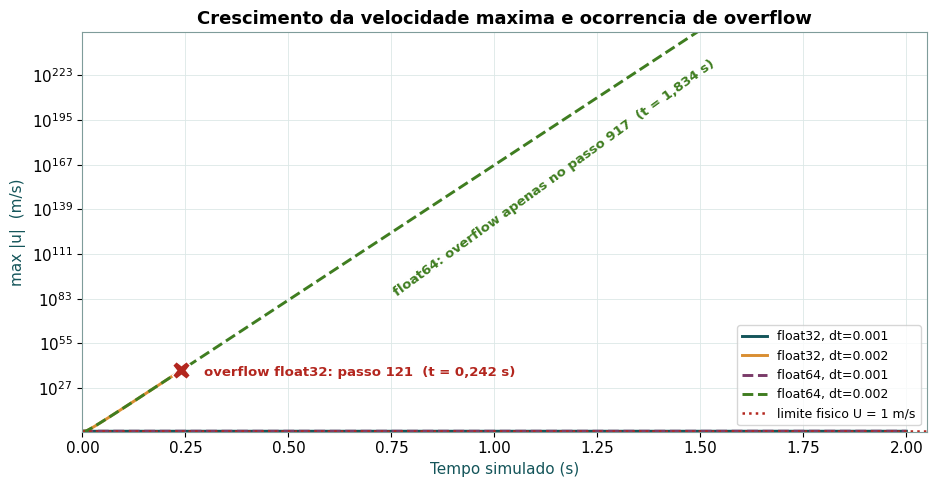

In [8]:
plt.figure(figsize=(9.5, 5))
for (nome, res), estilo in zip(resultados.items(), ["-", "-", "--", "--"]):
    plt.semilogy(res["tempos"], res["maximos"], estilo, linewidth=2.1, label=nome)

# Marca o instante exato do overflow em float32
r32 = resultados["float32, dt=0.002"]
plt.plot(r32["tempos"][-1], r32["maximos"][-1], "X", color="#B3261E",
         markersize=13, markeredgecolor="white", zorder=5)
plt.annotate("overflow float32: passo 121  (t = 0,242 s)",
             (r32["tempos"][-1], r32["maximos"][-1]), textcoords="offset points",
             xytext=(16, -4), fontsize=9.5, color="#B3261E", fontweight="600")
plt.annotate("float64: overflow apenas no passo 917  (t = 1,834 s)",
             (0.75, 1e85), fontsize=9.5, color="#3F7D20", fontweight="600", rotation=36)

plt.axhline(1.0, color="#B3261E", linestyle=":", linewidth=1.8,
            label="limite fisico U = 1 m/s")
plt.ylim(0.5, 1e250)
plt.xlim(0, 2.05)
plt.xlabel("Tempo simulado (s)")
plt.ylabel("max |u|  (m/s)")
plt.title("Crescimento da velocidade maxima e ocorrencia de overflow")
plt.grid(True, linewidth=0.6)
plt.legend(loc="lower right", frameon=True, facecolor="white", fontsize=9)
plt.tight_layout()
plt.show()

In [9]:
for nome in ("float32, dt=0.002", "float64, dt=0.002"):
    res = resultados[nome]
    k = next(i for i, v in enumerate(res["maximos"]) if v > 1 + 1e-6)
    print(f"{nome}")
    print(f"   solucao ultrapassa 1 m/s no passo {k} (t = {res['tempos'][k]:.3f} s), "
          f"valor = {res['maximos'][k]:.3f} m/s")
    print(f"   overflow apenas no passo {res['falha']}\n")

float32, dt=0.002
   solucao ultrapassa 1 m/s no passo 3 (t = 0.006 s), valor = 1.120 m/s
   overflow apenas no passo 121

float64, dt=0.002
   solucao ultrapassa 1 m/s no passo 3 (t = 0.006 s), valor = 1.120 m/s
   overflow apenas no passo 917



**Resposta.** Não há no problema qualquer mecanismo de geração de energia: a viscosidade apenas difunde o
movimento da placa para o interior do fluido. A solução física está, portanto, restrita a
$0 \le u(y,t) \le U = 1$ m/s. No caso instável, o máximo de $|u|$ ultrapassa esse limite **já no passo 3**
($t = 0{,}006$ s) e atinge $10^{8}$ m/s no passo 30 — magnitudes sem qualquer significado físico.

Dois aspectos merecem destaque:

- **A solução torna-se incorreta muito antes do *overflow*.** Em `float32` a falha só é sinalizada no passo 121;
  uma execução limitada a 100 passos não emitiria aviso algum e ainda assim produziria resultado inválido.
- **O crescimento é exponencial.** Com $1-2r < 0$, o modo de maior frequência representável na malha
  (alternância $+,-,+,-$ entre nós vizinhos) é multiplicado por um fator superior a 1 a cada iteração,
  o que caracteriza a instabilidade numérica — fenômeno distinto do *overflow*, que é apenas sua consequência final.

<div style="background-color:#14555A;border-left:7px solid #D98E32;border-radius:5px;padding:11px 18px;margin:26px 0 10px 0;"><span style="color:#D98E32;font-size:13px;letter-spacing:2px;font-weight:700;">SEÇÃO 4</span><br><span style="color:#FFFFFF;font-size:19px;font-weight:600;">Capacidade de representação: float32 e float64</span></div>

O fator de amplificação de cada modo da malha é $G_m = 1 - 4r\sin^{2}\!\big(m\pi/[2(N+1)]\big)$, com $N$ pontos
internos. A instabilidade é governada pelo modo de maior $|G_m|$.

In [10]:
r_b = 0.8
N = pontos - 2
m = np.arange(1, N + 1)
G = 1 - 4 * r_b * np.sin(m * np.pi / (2 * (N + 1)))**2
G_max = np.abs(G).max()

print(f"|G|max = {G_max:.4f}  ->  a amplitude cresce {G_max:.2f}x por passo\n")
print(f"{'Tipo':<10}{'Maior valor':>14}{'n estimado':>13}{'n real':>9}")
print("-" * 46)
for tipo in (np.float32, np.float64):
    maximo = float(np.finfo(tipo).max)
    n_est = np.log(maximo) / np.log(G_max)
    n_real = resultados[f"{tipo.__name__}, dt=0.002"]["falha"]
    print(f"{tipo.__name__:<10}{maximo:>14.2e}{n_est:>13.0f}{n_real:>9}")

m64 = resultados["float64, dt=0.002"]["maximos"]
print(f"\nCrescimento medido por passo (float64): {m64[-1]/m64[-2]:.4f}")

|G|max = 2.1803  ->  a amplitude cresce 2.18x por passo

Tipo         Maior valor   n estimado   n real
----------------------------------------------
float32         3.40e+38          114      121
float64        1.80e+308          911      917

Crescimento medido por passo (float64): 2.1803


**Resposta.** A alteração do tipo numérico **não elimina a instabilidade**. A instabilidade é uma propriedade
do *método* — decorre exclusivamente do valor de $r$ —, ao passo que o tipo numérico determina apenas o maior
valor representável. O `float64` executa a mesma recorrência divergente, apenas suportando magnitudes maiores
antes de sinalizar a falha.

O número de passos até o *overflow* pode ser estimado analiticamente. Como a amplitude cresce segundo
$|G|_{max}^{\,n} = 2{,}18^{\,n}$,

$$n \approx \frac{\ln\left(\text{maior valor do tipo}\right)}{\ln(2{,}18)}
\;\Rightarrow\; n_{32} \approx 114 \;(\text{real: }121), \qquad n_{64} \approx 911 \;(\text{real: }917).$$

A diferença entre os tipos decorre diretamente do expoente máximo: $10^{308}$ contra $10^{38}$, isto é,
oito vezes maior. Sendo exponencial o crescimento, são necessários aproximadamente oito vezes mais passos
($917/121 \approx 7{,}6$). Conclui-se que a maior precisão apenas **posterga** a manifestação do erro,
prolongando o intervalo em que resultados inválidos são produzidos sem qualquer aviso.

<div style="background-color:#14555A;border-left:7px solid #D98E32;border-radius:5px;padding:11px 18px;margin:26px 0 10px 0;"><span style="color:#D98E32;font-size:13px;letter-spacing:2px;font-weight:700;">SEÇÃO 5</span><br><span style="color:#FFFFFF;font-size:19px;font-weight:600;">Refinamento da malha</span></div>

In [11]:
for p in (21, 41):
    dy_p = H / (p - 1)
    print(f"{p} pontos -> dy = {dy_p:.5f} m | dt_max = {dy_p**2/(2*nu):.6f} s")

print(f"\n41 pontos mantendo dt = 0.001 s -> r = {nu*0.001/(H/40)**2:.2f}\n")

print(">>> 41 pontos, dt = 0.001 s")
res_41_instavel = simular(0.001, np.float64, passos=2000, pontos=41)

print("\n>>> 41 pontos, dt = 0.0002 s")
res_41_estavel = simular(0.0002, np.float64, passos=10000, pontos=41)
print(f"r = {res_41_estavel['r']:.2f} | max|u| final = {np.max(np.abs(res_41_estavel['u'])):.6f} m/s")

21 pontos -> dy = 0.00050 m | dt_max = 0.001250 s
41 pontos -> dy = 0.00025 m | dt_max = 0.000312 s

41 pontos mantendo dt = 0.001 s -> r = 1.60

>>> 41 pontos, dt = 0.001 s
dt=0.001, float64: falha no passo 426, t=0.4260 s - overflow encountered in subtract

>>> 41 pontos, dt = 0.0002 s
dt=0.0002, float64: 10000 passos sem overflow.
r = 0.32 | max|u| final = 1.000000 m/s


**Resposta.** Com 41 pontos, $\Delta y = 2{,}5\times10^{-4}$ m e $\Delta t_{max} = 3{,}125\times10^{-4}$ s.
Mantido $\Delta t = 0{,}001$ s — passo que era estável na malha anterior —, obtém-se $r = 1{,}60$ e a simulação
sofre *overflow* no passo **426** ($t = 0{,}426$ s).

O resultado ilustra um comportamento contraintuitivo do esquema explícito: o refinamento da malha, adotado
para aumentar a resolução espacial, **restringe** o limite de estabilidade. Como $\Delta t_{max} \propto \Delta y^{2}$,
a redução de $\Delta y$ pela metade divide o passo de tempo admissível por quatro. Adotando
$\Delta t = 2\times10^{-4}$ s, resulta $r = 0{,}32$ e a simulação percorre 10000 passos sem falha,
com $\max|u| = 1$ m/s.

<div style="background-color:#14555A;border-left:7px solid #D98E32;border-radius:5px;padding:11px 18px;margin:26px 0 10px 0;"><span style="color:#D98E32;font-size:13px;letter-spacing:2px;font-weight:700;">SEÇÃO 6</span><br><span style="color:#FFFFFF;font-size:19px;font-weight:600;">Verificação do perfil de velocidade</span></div>

In [12]:
res_bom = resultados["float64, dt=0.001"]
y = res_bom["y"]
u_num = res_bom["u"]
u_est = U * (1 - y / H)

E_inf = np.max(np.abs(u_num - u_est))
print(f"Tempo simulado: {res_bom['tempos'][-1]:.1f} s")
print(f"E_inf = max|u_i - u_est(y_i)| = {E_inf:.3e} m/s")

Tempo simulado: 2.0 s
E_inf = max|u_i - u_est(y_i)| = 1.605e-09 m/s


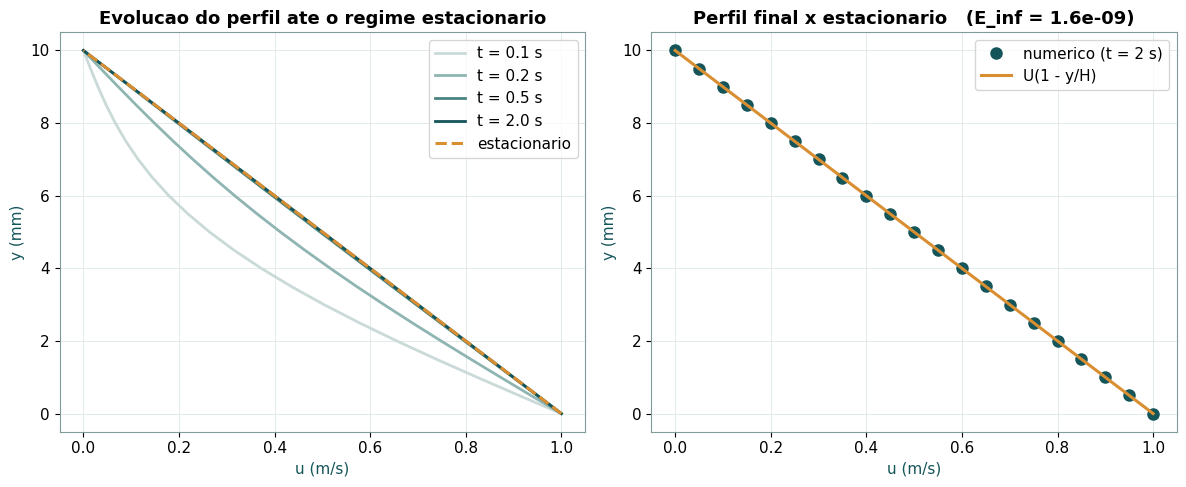

In [13]:
def perfil_em(dt, passos, pontos=21, tipo=np.float64):
    # Versao enxuta da simulacao: retorna apenas o perfil final
    dy_l = H / (pontos - 1)
    r_l, dois = tipo(nu * dt / dy_l**2), tipo(2)
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)
    for _ in range(passos):
        novo = u.copy()
        novo[1:-1] = u[1:-1] + r_l * (u[2:] - dois * u[1:-1] + u[:-2])
        u = novo
    return u

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for n_passos, cor in zip((100, 200, 500, 2000), ["#C9DAD8", "#8FB5B2", "#4A8480", "#14555A"]):
    ax1.plot(perfil_em(0.001, n_passos), y * 1000, color=cor, linewidth=2,
             label=f"t = {n_passos*0.001:.1f} s")
ax1.plot(u_est, y * 1000, "--", color="#D98E32", linewidth=2.2, label="estacionario")
ax1.set_xlabel("u (m/s)"); ax1.set_ylabel("y (mm)")
ax1.set_title("Evolucao do perfil ate o regime estacionario")
ax1.grid(True, linewidth=0.6); ax1.legend()

ax2.plot(u_num, y * 1000, "o", color="#14555A", markersize=8, label="numerico (t = 2 s)")
ax2.plot(u_est, y * 1000, "-", color="#D98E32", linewidth=2.2, label="U(1 - y/H)")
ax2.set_xlabel("u (m/s)"); ax2.set_ylabel("y (mm)")
ax2.set_title(f"Perfil final x estacionario   (E_inf = {E_inf:.1e})")
ax2.grid(True, linewidth=0.6); ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
print(f"{'t (s)':>8} | {'E_inf (m/s)':>12}")
print("-" * 25)
for n_passos in (100, 200, 500, 1000, 2000):
    E = np.max(np.abs(perfil_em(0.001, n_passos) - u_est))
    print(f"{n_passos*0.001:>8.1f} | {E:>12.3e}")

E32 = np.max(np.abs(perfil_em(0.001, 2000, tipo=np.float32) - u_est))
print(f"\nMesmo teste em float32 (t = 2 s): E_inf = {E32:.3e} m/s")

**Resposta.** Para a execução estável (21 pontos, $\Delta t = 0{,}001$ s, `float64`) até $t = 2$ s obtém-se

$$E_\infty = \max_i \left|u_i - u_{est}(y_i)\right| \approx 1{,}6\times10^{-9}\ \text{m/s},$$

com o perfil numérico praticamente coincidente com a reta $u_{est}(y) = U(1 - y/H)$.

O tempo simulado mostrou-se **suficiente**. O tempo característico de difusão é $H^{2}/\nu = 1$ s, e o
decaimento de $E_\infty$ é exponencial: $2{,}4\times10^{-1}$ em $t = 0{,}1$ s, $4{,}5\times10^{-3}$ em
$t = 0{,}5$ s e $1{,}6\times10^{-9}$ em $t = 2$ s. Em $t = 0{,}1$ s a diferença observada correspondia a 24% de $U$
e não constituía erro numérico, mas sim **transiente ainda não concluído** — o movimento da placa não havia
alcançado a parede oposta.

O resíduo final não decorre de erro de discretização: sendo linear a solução estacionária, sua segunda derivada
é nula e a diferença central a reproduz exatamente. Isso é confirmado pela repetição do teste em `float32`,
em que $E_\infty$ estabiliza em $\approx 2\times10^{-6}$ m/s — patamar imposto pelo arredondamento da precisão simples.

<div style="background-color:#14555A;border-left:7px solid #D98E32;border-radius:5px;padding:11px 18px;margin:26px 0 10px 0;"><span style="color:#D98E32;font-size:13px;letter-spacing:2px;font-weight:700;">SEÇÃO 7</span><br><span style="color:#FFFFFF;font-size:19px;font-weight:600;">Conclusão</span></div>

<div style="background-color:#EEF5F4;border:1px solid #CBDDDB;border-left:7px solid #D98E32;border-radius:5px;padding:16px 22px;font-size:15px;"><b style="color:#14555A;">Cadeia causal identificada</b><br><br>refinar a malha &nbsp;&rarr;&nbsp; &Delta;y &darr; &nbsp;&rarr;&nbsp; &Delta;t<sub>max</sub> = &Delta;y²/(2&nu;) &darr;&darr; &nbsp;&rarr;&nbsp; r = &nu;&Delta;t/&Delta;y² &uarr; &nbsp;&rarr;&nbsp; <b style="color:#B3261E;">instabilidade</b> &nbsp;&rarr;&nbsp; <b style="color:#B3261E;">overflow</b></div>

O esquema de Euler explícito é estável apenas enquanto $r \le 1/2$; nessa faixa, a atualização é uma média
ponderada de coeficientes não negativos e nenhum valor novo excede o intervalo dos anteriores. Excedido o
limite, o coeficiente central torna-se negativo e o modo de maior frequência da malha passa a ser amplificado
por um fator superior à unidade a cada iteração — 2,18 no caso analisado —, produzindo crescimento exponencial.

A solução perde validade física quase imediatamente (passo 3), enquanto o *overflow* ocorre apenas quando as
magnitudes ultrapassam o maior valor representável do tipo ($3{,}4\times10^{38}$ em `float32`;
$1{,}8\times10^{308}$ em `float64`). Confirma-se, assim, que **instabilidade e *overflow* são fenômenos distintos**:
o segundo é consequência tardia do primeiro. Verificou-se ainda que o refinamento da malha agrava a restrição
de forma quadrática, exigindo a redução simultânea do passo de tempo.

**Correção efetiva:** a redução do passo de tempo de modo a satisfazer $\Delta t \le \Delta y^{2}/(2\nu)$ — de
0,002 s para 0,001 s na malha de 21 pontos, e de 0,001 s para 0,0002 s na malha de 41 pontos.

**Medida ineficaz:** a substituição de `float32` por `float64`, que apenas transferiu a falha do passo 121 para
o passo 917, ampliando o intervalo de produção de resultados inválidos sem sinalização.

Depreende-se, por fim, que a ausência de mensagens de erro não constitui evidência de correção do resultado.
A validação exige a verificação prévia do critério de estabilidade e a conferência da consistência física da
solução — neste caso, a permanência de $u$ no intervalo $[0, U]$.